In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(os.listdir("/content/drive/MyDrive/Supply_Chain_Analytics/01_Raw_Data"))

['DataCoSupplyChainDataset.csv', 'DataCoSupplyChainDataset_Cleaned.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/content/drive/MyDrive/Supply_Chain_Analytics/01_Raw_Data/DataCoSupplyChainDataset.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 180519
Columns: 53


In [ ]:
# Remove columns with no/mostly missing useful information
df = df.drop(columns=["Product Description", "Order Zipcode"], errors="ignore")

# Handle small missing values
df["Customer Lname"] = df["Customer Lname"].fillna("Unknown")
df["Customer Zipcode"] = df["Customer Zipcode"].fillna(0)

# Convert dates
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"]
)

df["shipping date (DateOrders)"] = pd.to_datetime(
    df["shipping date (DateOrders)"]
)

# Create date features
df["Order_Year"] = df["order date (DateOrders)"].dt.year
df["Order_Month"] = df["order date (DateOrders)"].dt.month
df["Order_Day"] = df["order date (DateOrders)"].dt.day
df["Order_Quarter"] = df["order date (DateOrders)"].dt.quarter
df["Order_DayOfWeek"] = df["order date (DateOrders)"].dt.dayofweek

# Create delivery delay
df["Delivery_Delay"] = (
    df["Days for shipping (real)"]
    - df["Days for shipment (scheduled)"]
)

print("Cleaning and feature engineering completed!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())

Cleaning and feature engineering completed!
Rows: 180519
Columns: 57
Missing values: 0


In [ ]:
cleaned_path = "/content/drive/MyDrive/Supply_Chain_Analytics/01_Raw_Data/DataCoSupplyChainDataset_Cleaned.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved to Google Drive!")

Cleaned dataset saved to Google Drive!


In [ ]:
category_sales = (
    df.groupby("Category Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category Name
Fishing                 6.929654e+06
Cleats                  4.431943e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113845e+06
Men's Footwear          2.891758e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309522e+06
Computers               6.630000e+05
Electronics             3.710346e+05
Cameras                 2.676077e+05
Garden                  2.577687e+05
Children's Clothing     2.328292e+05
Crafts                  2.233563e+05
Girls' Apparel          1.517062e+05
Women's Clothing        1.402830e+05
Accessories             1.336715e+05
Sporting Goods          1.170068e+05
Golf Gloves             1.166954e+05
Music                   1.131221e+05
Consumer Electronics    1.089913e+05
Golf Shoes              1.079980e+05
Health and Beauty       1.060805e+05
Kids' Golf Clubs        9.879758e+04
Baseball & Softball     9.405715e+04
Boxing & MMA            

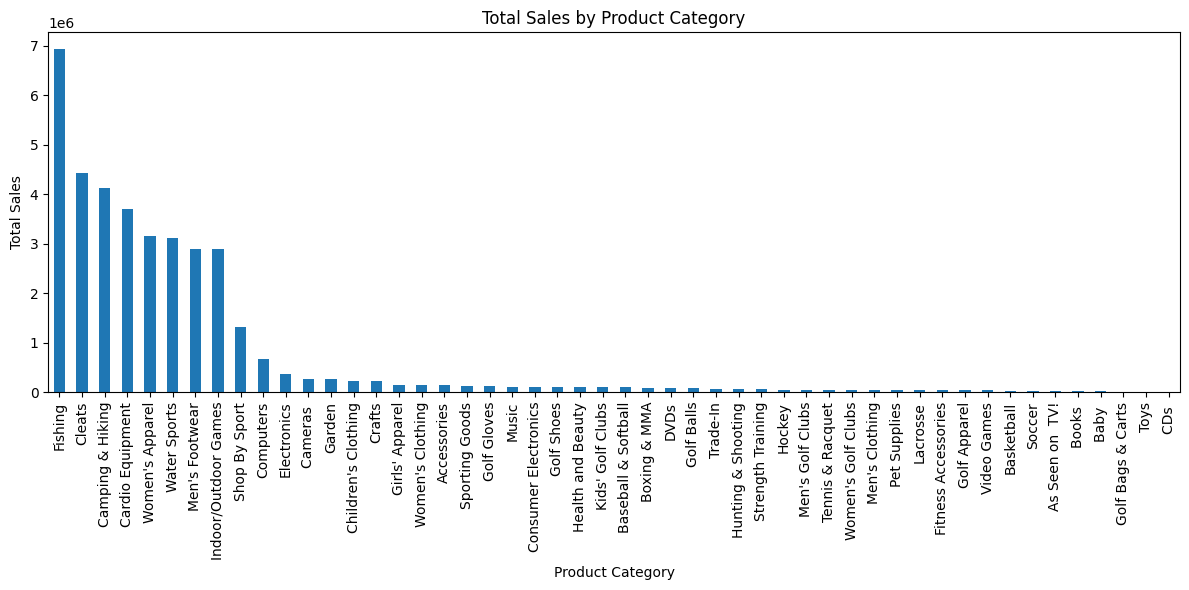

In [ ]:
plt.figure(figsize=(12, 6))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
market_sales = (
    df.groupby("Market")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(market_sales)

Market
Europe          1.087240e+07
LATAM           1.027761e+07
Pacific Asia    8.273744e+06
USCA            5.066529e+06
Africa          2.294453e+06
Name: Sales, dtype: float64


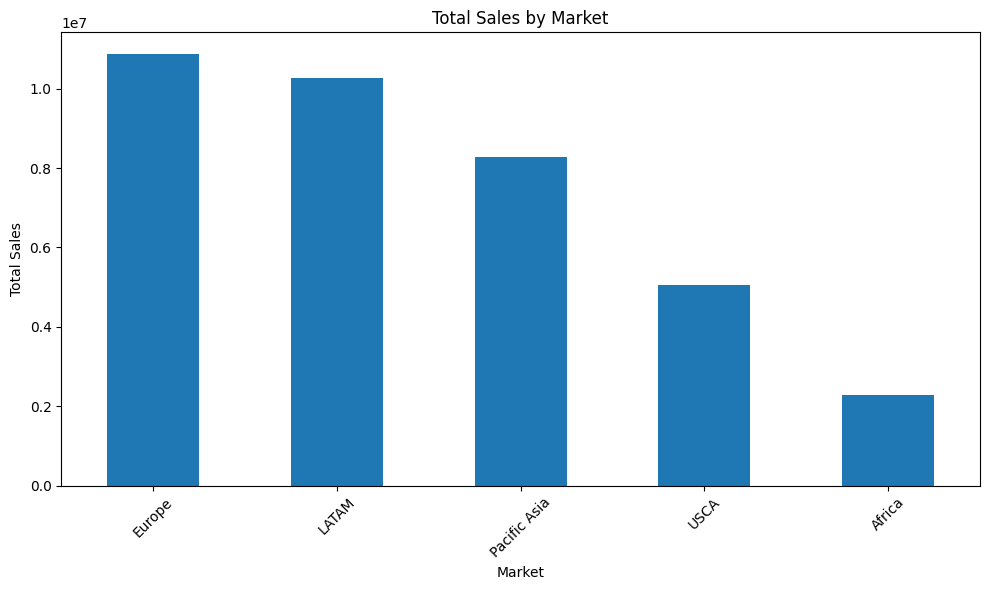

In [ ]:
plt.figure(figsize=(10, 6))

market_sales.plot(kind="bar")

plt.title("Total Sales by Market")
plt.xlabel("Market")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
region_sales = (
    df.groupby("Order Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Order Region
Western Europe     5.894381e+06
Central America    5.665712e+06
South America      2.960881e+06
Northern Europe    2.155831e+06
Southern Europe    2.047919e+06
Oceania            2.016654e+06
Southeast Asia     1.932496e+06
Caribbean          1.651019e+06
West of USA        1.571416e+06
South Asia         1.553681e+06
Eastern Asia       1.486401e+06
East of USA        1.371112e+06
West Asia          1.174672e+06
US Center          1.151356e+06
South of  USA      7.857839e+05
Eastern Europe     7.742666e+05
West Africa        7.279512e+05
North Africa       6.347522e+05
East Africa        3.762349e+05
Central Africa     3.272630e+05
Southern Africa    2.282516e+05
Canada             1.868610e+05
Central Asia       1.098399e+05
Name: Sales, dtype: float64


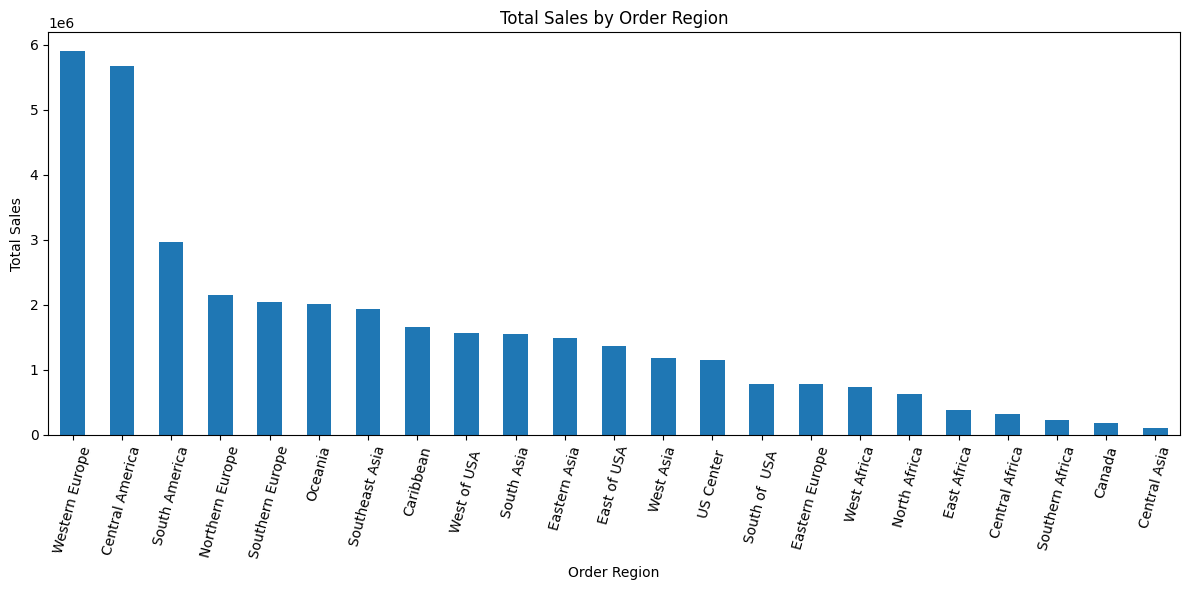

In [ ]:
plt.figure(figsize=(12, 6))

region_sales.plot(kind="bar")

plt.title("Total Sales by Order Region")
plt.xlabel("Order Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:
monthly_sales = (
    df.groupby(["Order_Year", "Order_Month"])["Sales"]
      .sum()
      .reset_index()
)

print(monthly_sales.head(12))

    Order_Year  Order_Month         Sales
0         2015            1  1.051590e+06
1         2015            2  9.270099e+05
2         2015            3  1.051254e+06
3         2015            4  1.014463e+06
4         2015            5  1.050478e+06
5         2015            6  1.024006e+06
6         2015            7  1.038081e+06
7         2015            8  1.029495e+06
8         2015            9  1.018339e+06
9         2015           10  1.049154e+06
10        2015           11  1.029120e+06
11        2015           12  1.057841e+06


In [ ]:
monthly_sales["Year_Month"] = pd.to_datetime(
    monthly_sales["Order_Year"].astype(str)
    + "-"
    + monthly_sales["Order_Month"].astype(str)
    + "-01"
)

monthly_sales = monthly_sales.sort_values("Year_Month")

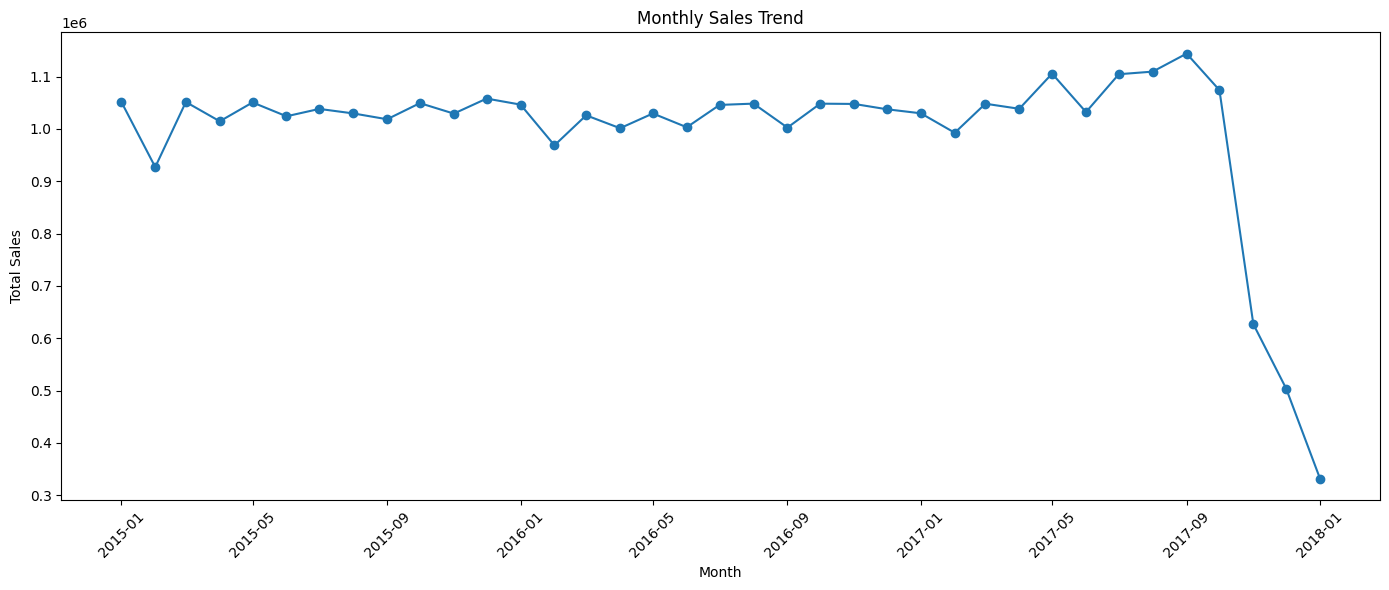

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Year_Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
profit_by_category = (
    df.groupby("Category Name")["Order Profit Per Order"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_by_category)

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Electronics              40891.379918
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27178.099597
Crafts                   25531.170060
Women's Clothing         19102.849930
Girls' Apparel           17288.569973
Accessories              16643.520074
Music                    14436.319923
Consumer Electronics     13223.399926
Golf Gloves              12975.490078
Baseball & Softball      12762.130067
Sporting Goods           12518.610119
Golf Shoes               12406.070143
Health and Beauty         9493.629974
Kids' Golf Clubs          9045.83989

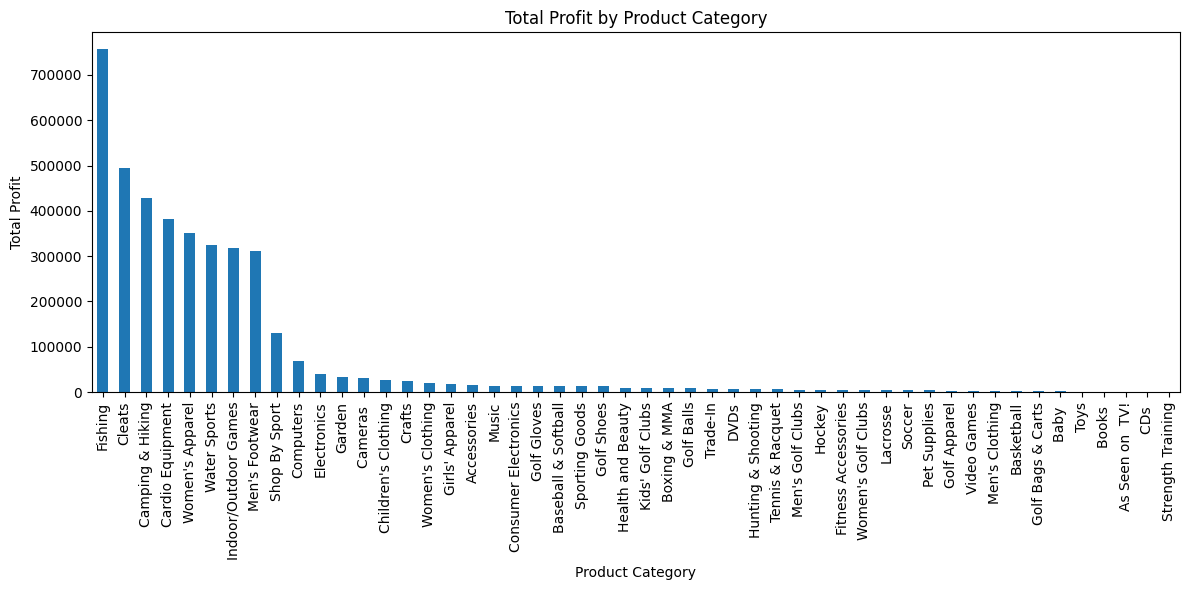

In [ ]:
plt.figure(figsize=(12, 6))

profit_by_category.plot(kind="bar")

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df["Delivery_Performance"] = np.where(
    df["Delivery_Delay"] > 0,
    "Late",
    np.where(
        df["Delivery_Delay"] == 0,
        "On Time",
        "Early"
    )
)

print(df["Delivery_Performance"].value_counts())

Delivery_Performance
Late       103400
Early       43366
On Time     33753
Name: count, dtype: int64


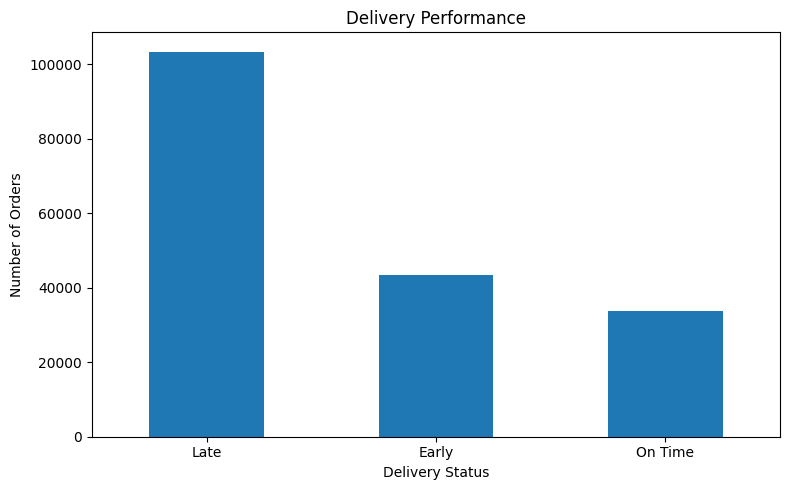

In [ ]:
delivery_counts = df["Delivery_Performance"].value_counts()

plt.figure(figsize=(8, 5))

delivery_counts.plot(kind="bar")

plt.title("Delivery Performance")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
late_by_shipping = (
    df[df["Delivery_Performance"] == "Late"]
    .groupby("Shipping Mode")
    .size()
    .sort_values(ascending=False)
)

print(late_by_shipping)

Shipping Mode
Standard Class    42851
Second Class      28078
First Class       27814
Same Day           4657
dtype: int64


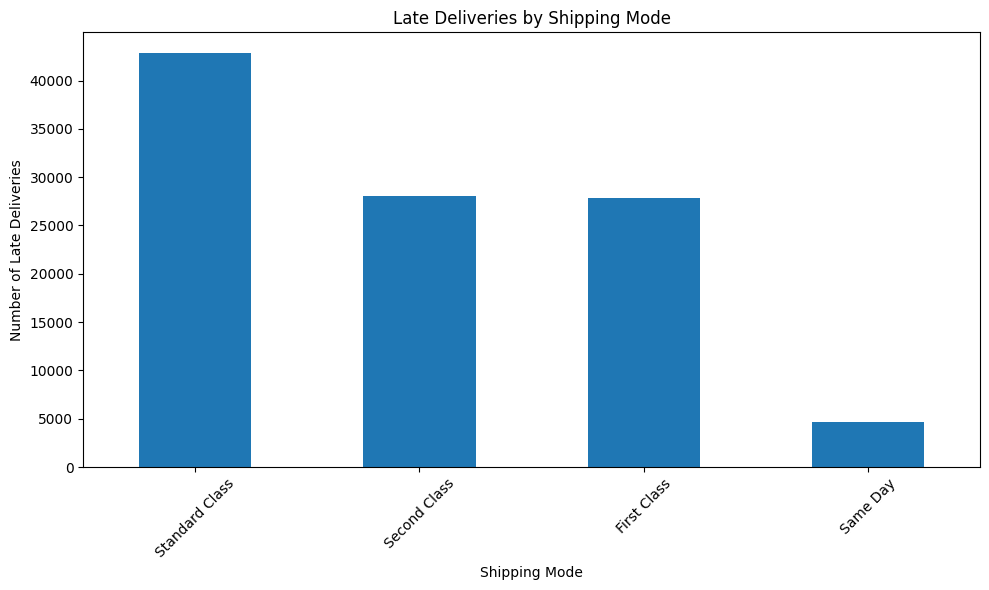

In [ ]:
plt.figure(figsize=(10, 6))

late_by_shipping.plot(kind="bar")

plt.title("Late Deliveries by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Late Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
total_by_shipping = df.groupby("Shipping Mode").size()

In [ ]:
late_by_shipping = (
    df[df["Delivery_Performance"] == "Late"]
    .groupby("Shipping Mode")
    .size()
)

In [ ]:
late_percentage = (
    late_by_shipping / total_by_shipping * 100
).sort_values(ascending=False)

print(late_percentage)

Shipping Mode
First Class       100.000000
Second Class       79.730804
Same Day           47.827873
Standard Class     39.768171
dtype: float64


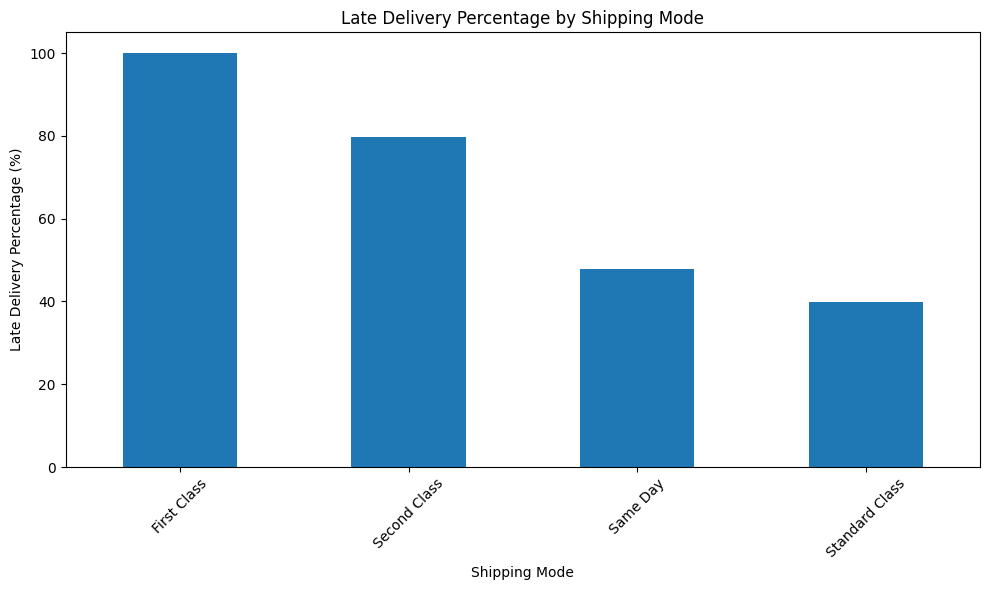

In [ ]:
plt.figure(figsize=(10, 6))

late_percentage.plot(kind="bar")

plt.title("Late Delivery Percentage by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
segment_sales = (
    df.groupby("Customer Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_sales)

Customer Segment
Consumer       1.909579e+07
Corporate      1.116841e+07
Home Office    6.520538e+06
Name: Sales, dtype: float64


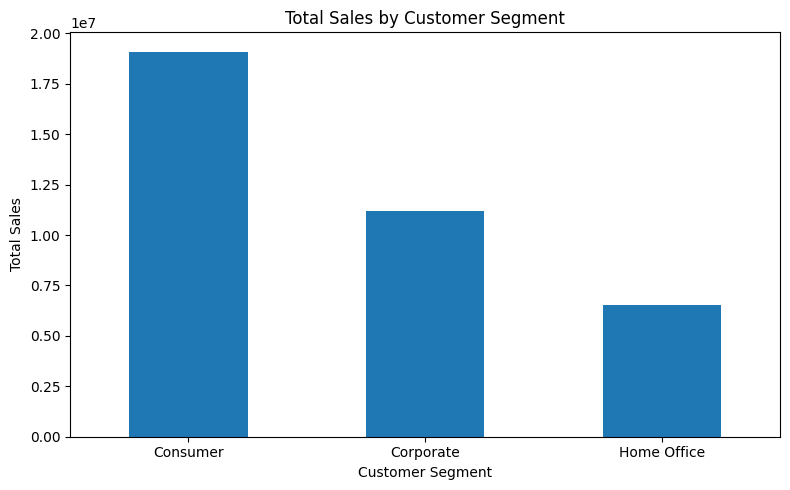

In [ ]:
plt.figure(figsize=(8, 5))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
product_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(product_sales.head(10))

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        6.929654e+06
Perfect Fitness Perfect Rip Deck                 4.421143e+06
Diamondback Women's Serene Classic Comfort Bi    4.118426e+06
Nike Men's Free 5.0+ Running Shoe                3.667633e+06
Nike Men's Dri-FIT Victory Golf Polo             3.147800e+06
Pelican Sunstream 100 Kayak                      3.099845e+06
Nike Men's CJ Elite 2 TD Football Cleat          2.891758e+06
O'Brien Men's Neoprene Life Vest                 2.888994e+06
Under Armour Girls' Toddler Spine Surge Runni    1.269083e+06
Dell Laptop                                      6.630000e+05
Name: Sales, dtype: float64


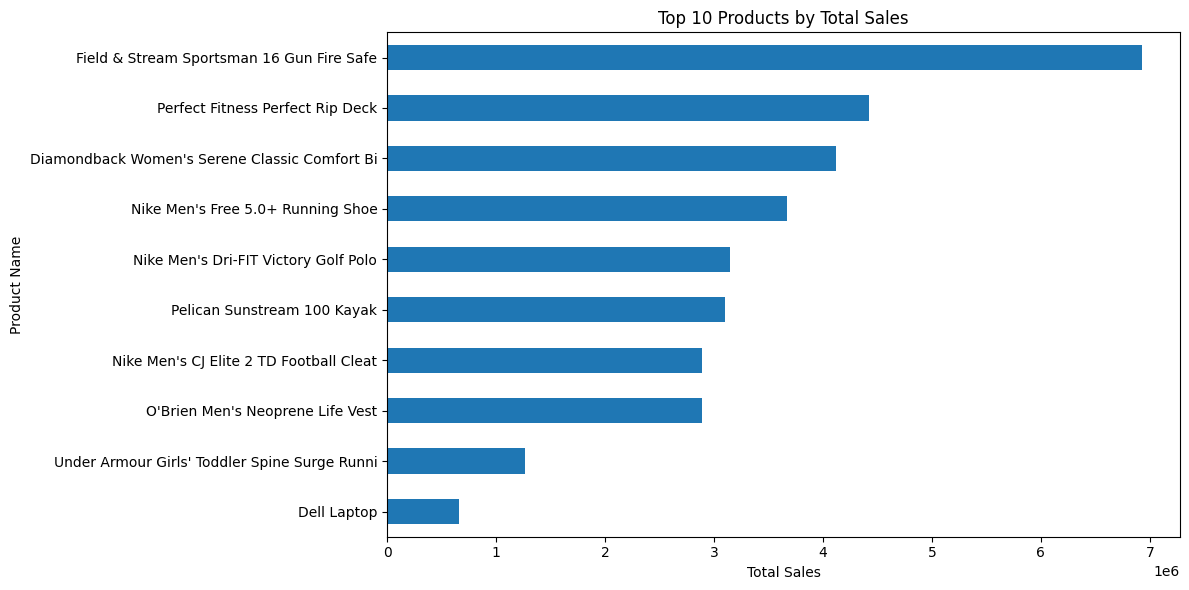

In [ ]:
top_10_products = product_sales.head(10)

plt.figure(figsize=(12, 6))

top_10_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [ ]:
product_profit = (
    df.groupby("Product Name")["Order Profit Per Order"]
      .sum()
      .sort_values(ascending=False)
)

print(product_profit.head(10))

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        756220.767190
Perfect Fitness Perfect Rip Deck                 493828.299782
Diamondback Women's Serene Classic Comfort Bi    427455.568106
Nike Men's Free 5.0+ Running Shoe                379915.818503
Nike Men's Dri-FIT Victory Golf Polo             350421.029567
Pelican Sunstream 100 Kayak                      324076.370020
O'Brien Men's Neoprene Life Vest                 318451.430554
Nike Men's CJ Elite 2 TD Football Cleat          311902.820214
Under Armour Girls' Toddler Spine Surge Runni    126278.510299
Dell Laptop                                       69656.810171
Name: Order Profit Per Order, dtype: float64


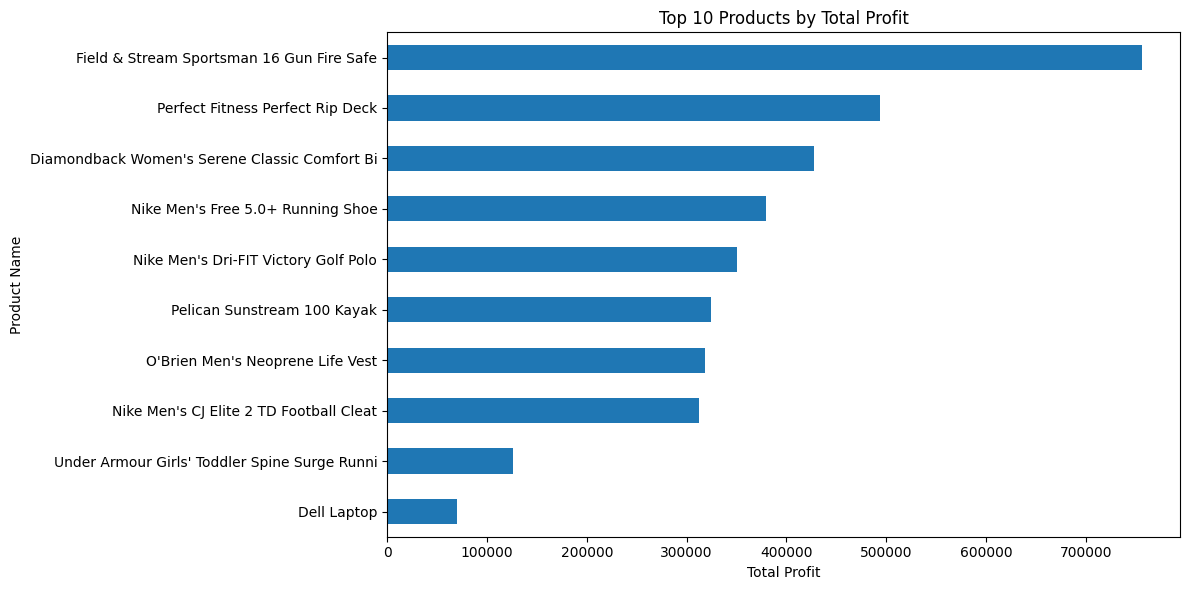

In [ ]:
top_10_profit = product_profit.head(10)

plt.figure(figsize=(12, 6))

top_10_profit.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [ ]:
yearly_sales = (
    df.groupby("Order_Year")["Sales"]
      .sum()
)

print(yearly_sales)

Order_Year
2015    1.234083e+07
2016    1.230382e+07
2017    1.180844e+07
2018    3.316501e+05
Name: Sales, dtype: float64


In [ ]:
yearly_profit = (
    df.groupby("Order_Year")["Order Profit Per Order"]
      .sum()
)

print(yearly_profit)

Order_Year
2015    1.318857e+06
2016    1.310119e+06
2017    1.304085e+06
2018    3.384189e+04
Name: Order Profit Per Order, dtype: float64


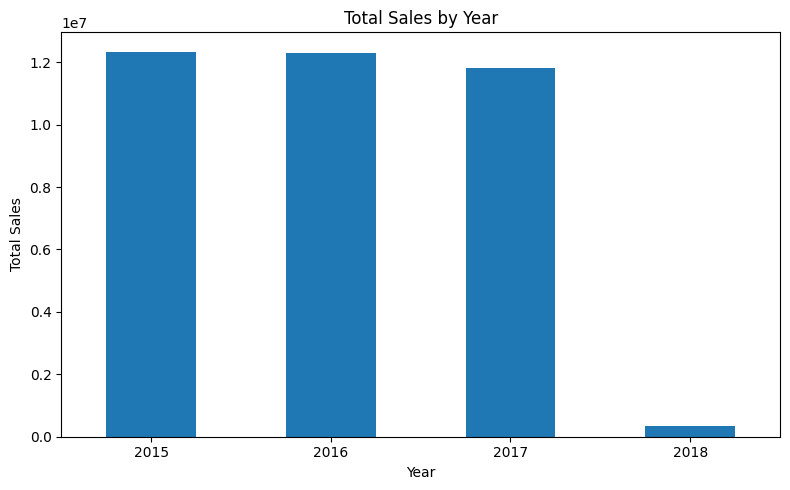

In [ ]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind="bar")

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

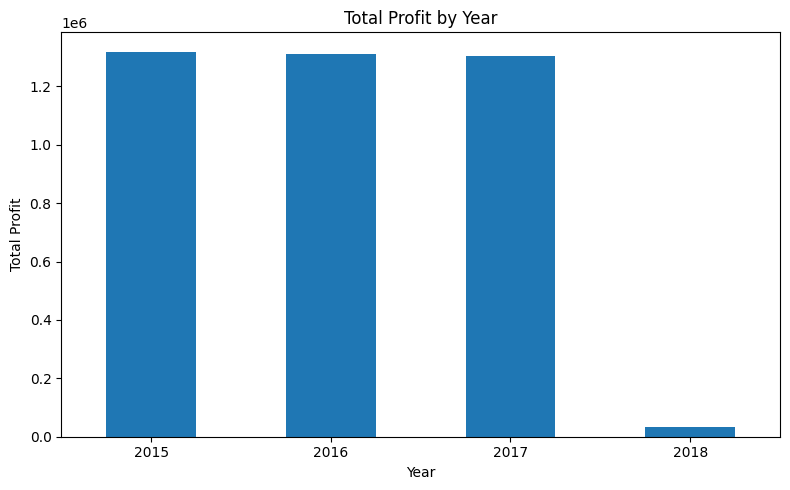

In [ ]:
plt.figure(figsize=(8, 5))

yearly_profit.plot(kind="bar")

plt.title("Total Profit by Year")
plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
region_sales = (
    df.groupby("Order Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Order Region
Western Europe     5.894381e+06
Central America    5.665712e+06
South America      2.960881e+06
Northern Europe    2.155831e+06
Southern Europe    2.047919e+06
Oceania            2.016654e+06
Southeast Asia     1.932496e+06
Caribbean          1.651019e+06
West of USA        1.571416e+06
South Asia         1.553681e+06
Eastern Asia       1.486401e+06
East of USA        1.371112e+06
West Asia          1.174672e+06
US Center          1.151356e+06
South of  USA      7.857839e+05
Eastern Europe     7.742666e+05
West Africa        7.279512e+05
North Africa       6.347522e+05
East Africa        3.762349e+05
Central Africa     3.272630e+05
Southern Africa    2.282516e+05
Canada             1.868610e+05
Central Asia       1.098399e+05
Name: Sales, dtype: float64


In [ ]:
region_profit = (
    df.groupby("Order Region")["Order Profit Per Order"]
      .sum()
      .sort_values(ascending=False)
)

print(region_profit)

Order Region
Western Europe     625446.080548
Central America    616341.570651
South America      335154.400817
Northern Europe    233450.600647
Southern Europe    230829.229883
Southeast Asia     211342.819786
Oceania            201478.020484
Caribbean          171825.640024
South Asia         165703.900124
West of USA        164940.660455
East of USA        156263.300194
Eastern Asia       147368.010614
US Center          131094.229875
West Asia          118815.410047
South of  USA       88114.879898
West Africa         80030.270031
Eastern Europe      79717.049920
North Africa        64599.860009
East Africa         43167.729927
Central Africa      33447.269960
Southern Africa     30826.050146
Canada              23900.709960
Central Asia        13045.280051
Name: Order Profit Per Order, dtype: float64


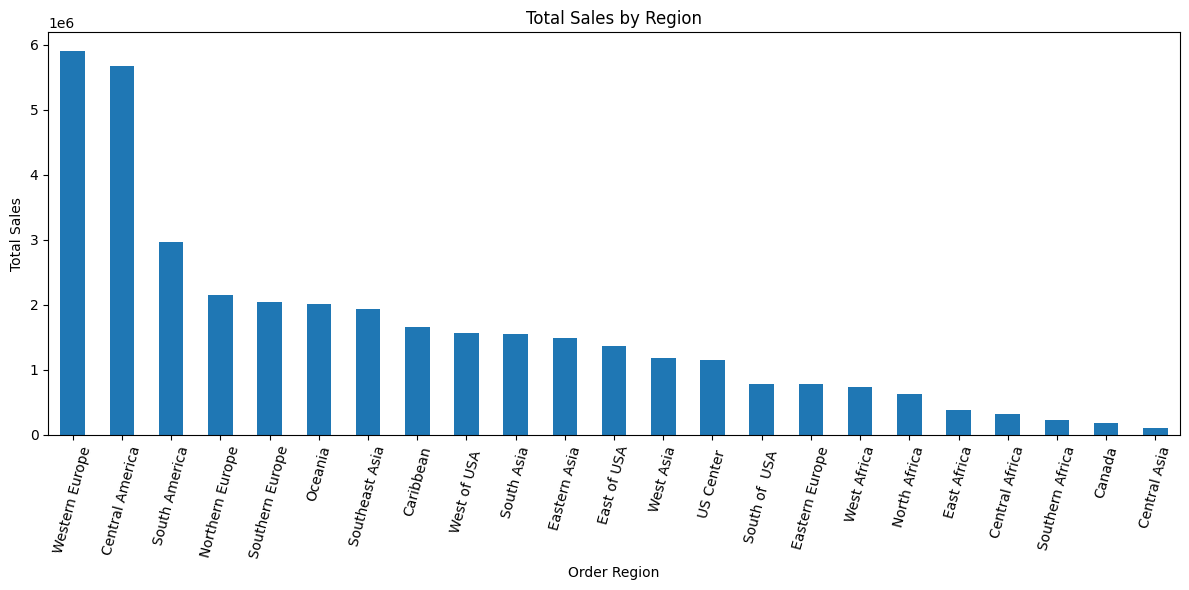

In [ ]:
plt.figure(figsize=(12, 6))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Order Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

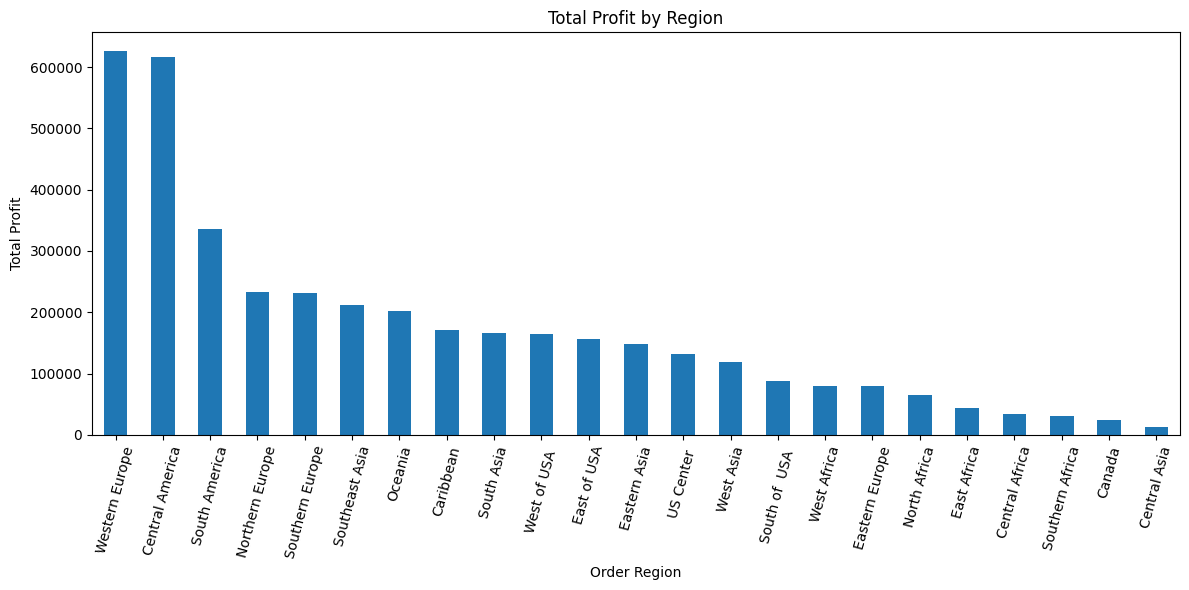

In [ ]:
plt.figure(figsize=(12, 6))

region_profit.plot(kind="bar")

plt.title("Total Profit by Region")
plt.xlabel("Order Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:
segment_profit = (
    df.groupby("Customer Segment")["Order Profit Per Order"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_profit)

Customer Segment
Consumer       2.073488e+06
Corporate      1.202575e+06
Home Office    6.908403e+05
Name: Order Profit Per Order, dtype: float64


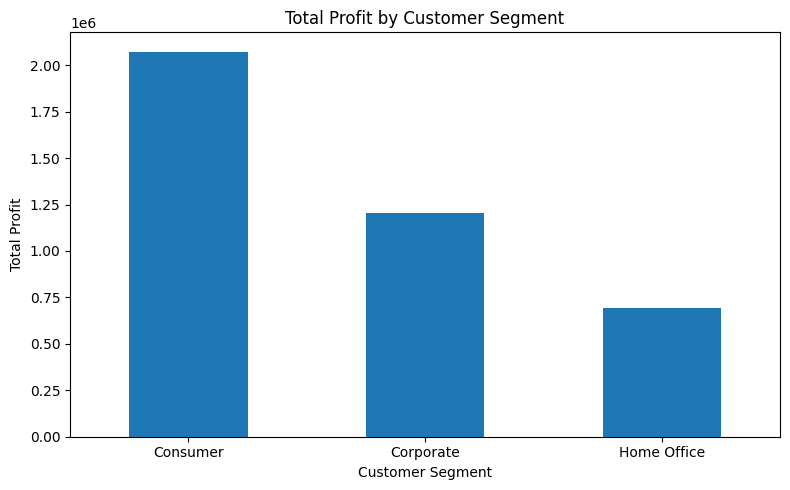

In [ ]:
plt.figure(figsize=(8, 5))

segment_profit.plot(kind="bar")

plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
order_status = df["Order Status"].value_counts()

print(order_status)

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64


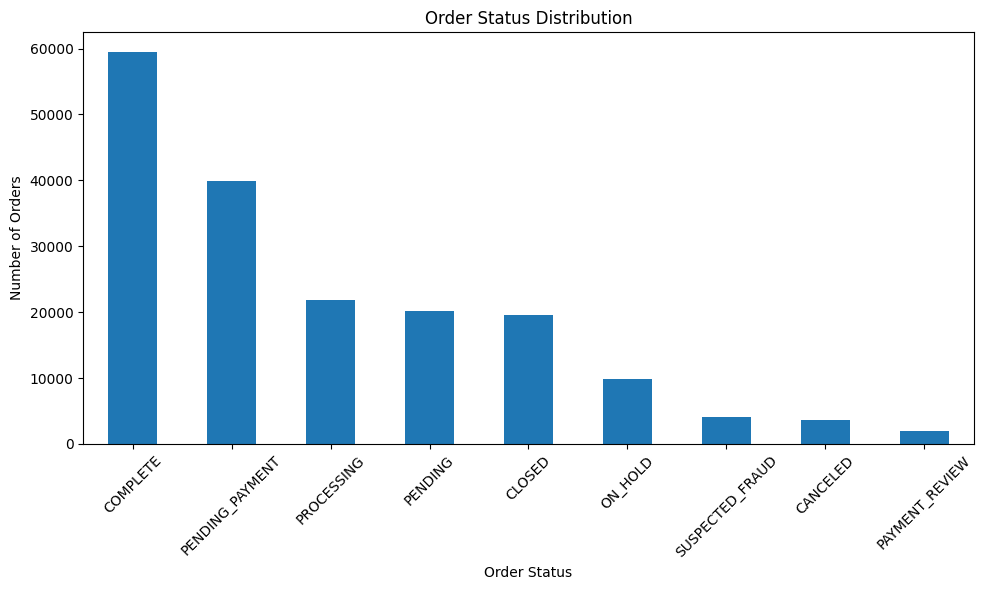

In [ ]:
plt.figure(figsize=(10, 6))

order_status.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
segment_market_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Customer Segment",
    columns="Market",
    aggfunc="sum"
)

print(segment_market_sales)

Market                  Africa        Europe         LATAM  Pacific Asia  \
Customer Segment                                                           
Consumer          1.187434e+06  5.671565e+06  5.289639e+06  4.286861e+06   
Corporate         6.997575e+05  3.303071e+06  3.139115e+06  2.515593e+06   
Home Office       4.072613e+05  1.897761e+06  1.848859e+06  1.471290e+06   

Market                    USCA  
Customer Segment                
Consumer          2.660291e+06  
Corporate         1.510871e+06  
Home Office       8.953663e+05  


<Figure size 1200x600 with 0 Axes>

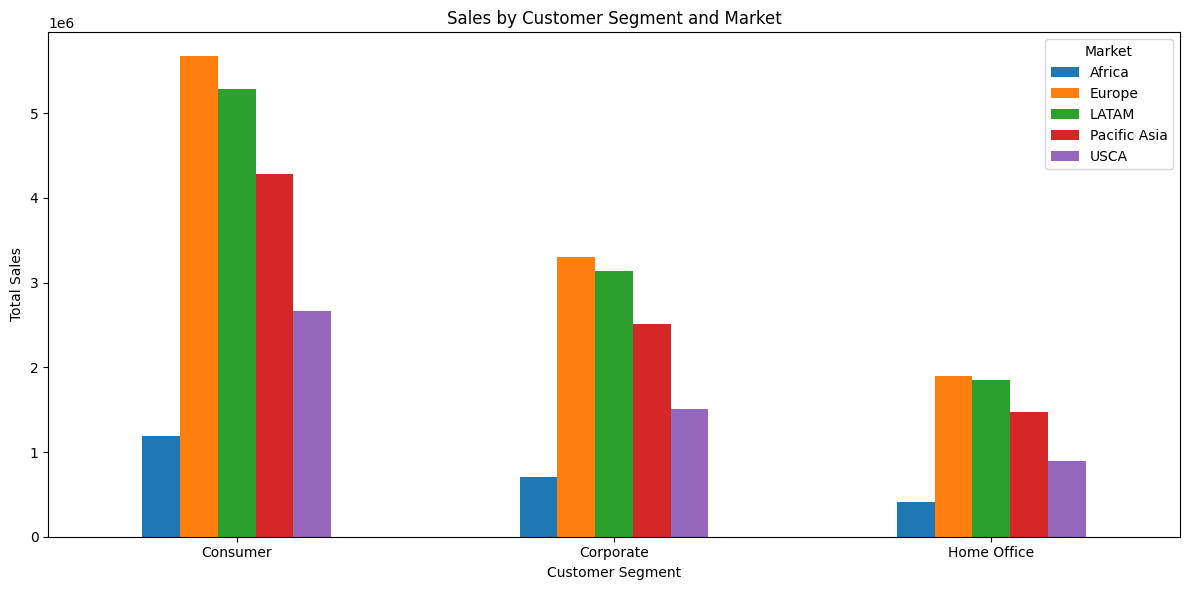

In [ ]:
plt.figure(figsize=(12, 6))

segment_market_sales.plot(kind="bar", figsize=(12, 6))

plt.title("Sales by Customer Segment and Market")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
shipping_columns = [
    col for col in df.columns
    if "shipping" in col.lower()
]

print(shipping_columns)

['Days for shipping (real)', 'shipping date (DateOrders)', 'Shipping Mode']


In [ ]:
shipping_columns = [
    col for col in df.columns
    if "shipping" in col.lower()
]

print(shipping_columns)

['Days for shipping (real)', 'shipping date (DateOrders)', 'Shipping Mode']


In [ ]:
avg_delay_shipping = (
    df.groupby("Shipping Mode")["Delivery_Delay"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_delay_shipping)

Shipping Mode
Second Class      1.990828
First Class       1.000000
Same Day          0.478279
Standard Class   -0.004093
Name: Delivery_Delay, dtype: float64


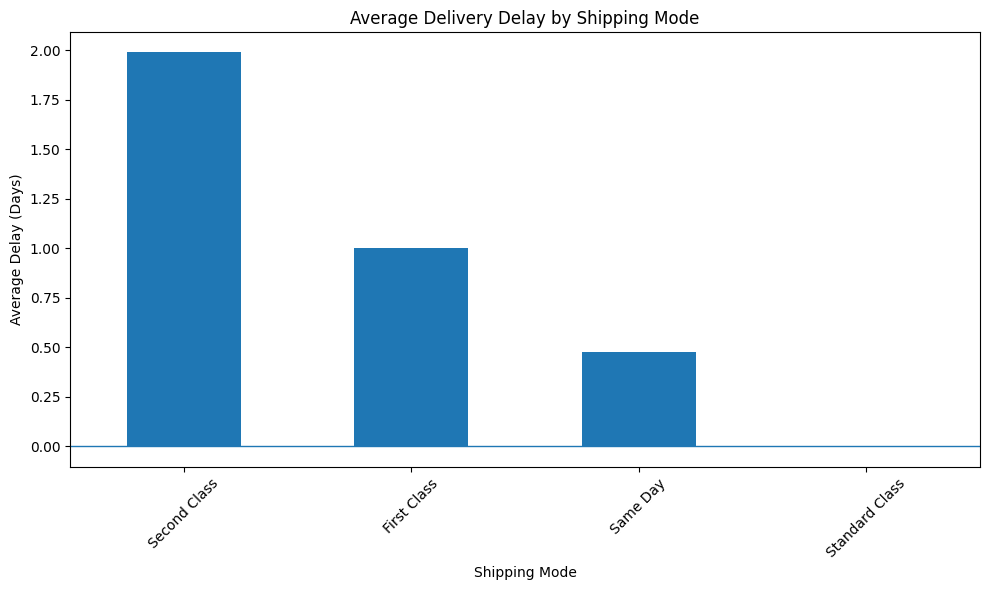

In [ ]:
plt.figure(figsize=(10, 6))

avg_delay_shipping.plot(kind="bar")

plt.title("Average Delivery Delay by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
correlation = df["Sales"].corr(df["Order Profit Per Order"])

print("Sales-Profit Correlation:", correlation)

Sales-Profit Correlation: 0.1318155893367278


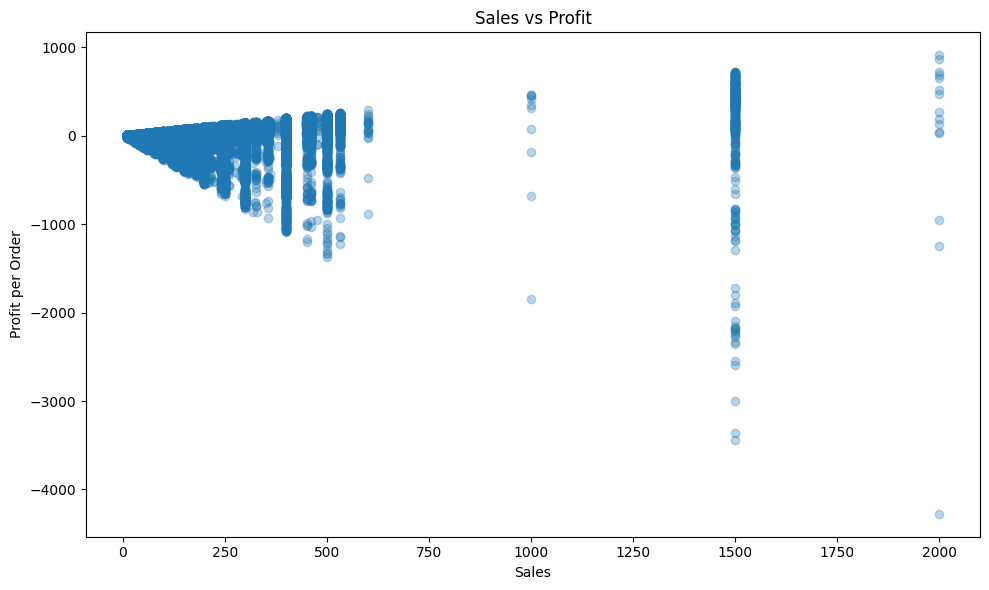

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Sales"],
    df["Order Profit Per Order"],
    alpha=0.3
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit per Order")
plt.tight_layout()
plt.show()

In [ ]:
avg_sales_segment = (
    df.groupby("Customer Segment")["Sales"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_sales_segment)

Customer Segment
Consumer       204.224313
Corporate      203.843962
Home Office    202.337802
Name: Sales, dtype: float64


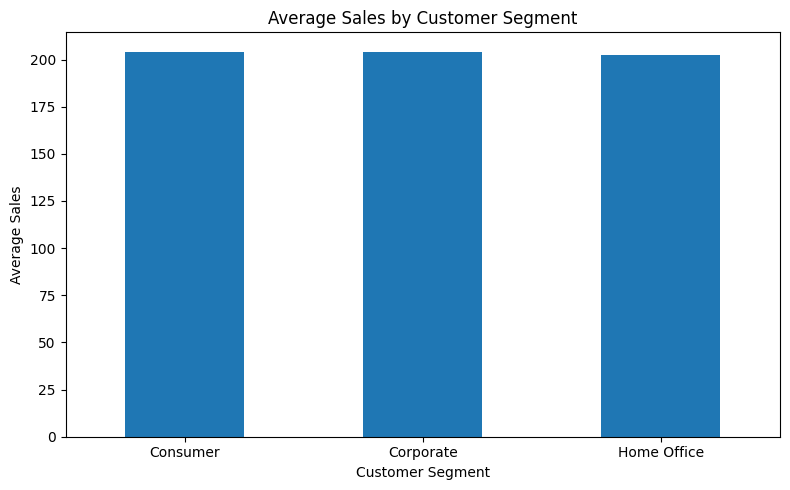

In [ ]:
plt.figure(figsize=(8, 5))

avg_sales_segment.plot(kind="bar")

plt.title("Average Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
category_market_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Category Name",
    columns="Market",
    aggfunc="sum"
)

print(category_market_sales)

Market                       Africa        Europe         LATAM  Pacific Asia  \
Category Name                                                                   
Accessories            11545.379885  2.793882e+04  3.726009e+04  3.318672e+04   
As Seen on  TV!                 NaN  1.299870e+04  7.599240e+03           NaN   
Baby                            NaN  4.844560e+03           NaN  7.385000e+03   
Baseball & Softball     8058.340194  2.221643e+04  2.993953e+04  1.842602e+04   
Basketball                      NaN  2.709933e+04           NaN           NaN   
Books                           NaN  9.572640e+03           NaN  3.014760e+03   
Boxing & MMA            5222.150116  3.265241e+04  2.798141e+04  1.077412e+04   
CDs                             NaN  1.501570e+03           NaN  1.558020e+03   
Cameras                         NaN  2.599230e+05           NaN  7.684680e+03   
Camping & Hiking      265182.329724  1.137824e+06  1.259916e+06  8.393441e+05   
Cardio Equipment      257174

<Figure size 1400x800 with 0 Axes>

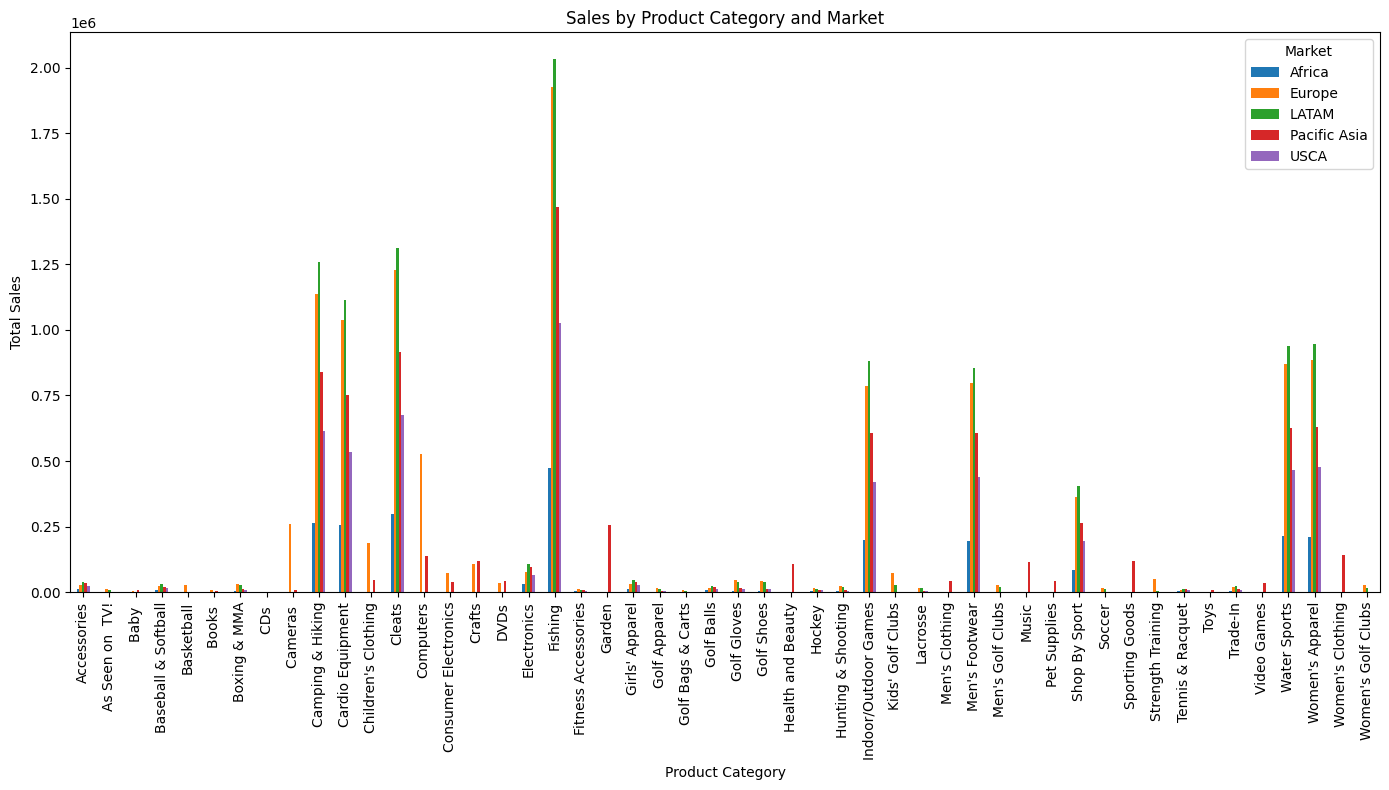

In [ ]:
plt.figure(figsize=(14, 8))

category_market_sales.plot(
    kind="bar",
    figsize=(14, 8)
)

plt.title("Sales by Product Category and Market")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
city_sales = (
    df.groupby("Order City")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(city_sales.head(10))

Order City
New York City    436061.538159
Santo Domingo    432351.878303
Los Angeles      370545.137497
Tegucigalpa      364129.987113
Managua          335424.756486
Mexico City      298471.835883
Manila           271819.805030
San Francisco    256245.625345
Philadelphia     255914.244948
London           255151.244618
Name: Sales, dtype: float64


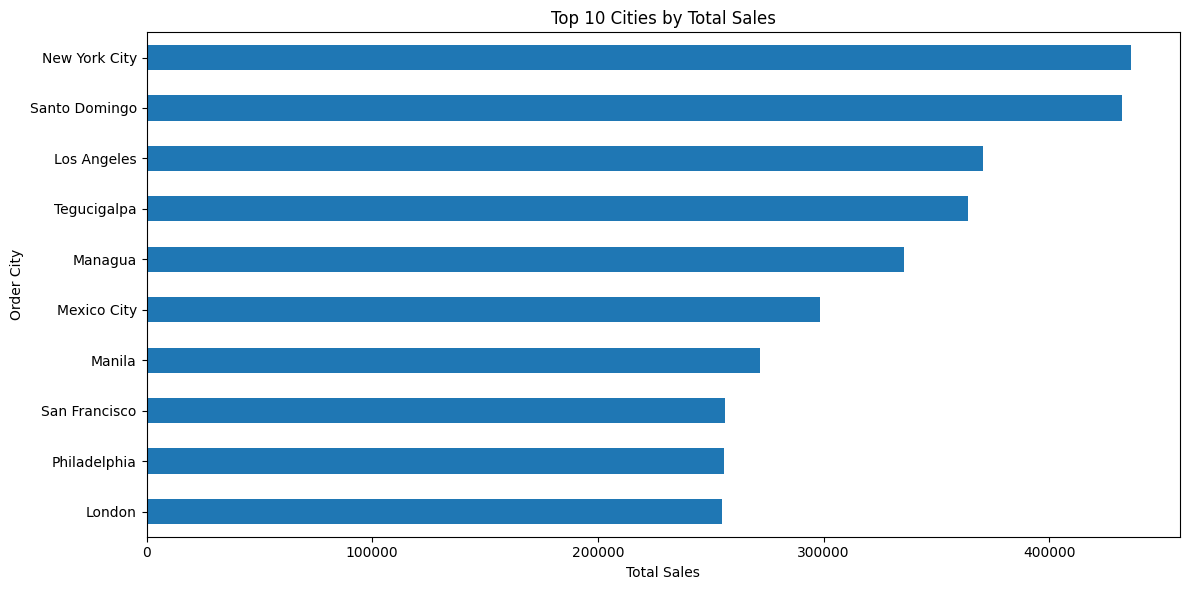

In [ ]:
top_10_cities = city_sales.head(10)

plt.figure(figsize=(12, 6))

top_10_cities.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Order City")
plt.tight_layout()
plt.show()

In [ ]:
country_sales = (
    df.groupby("Order Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(country_sales.head(10))

Order Country
Estados Unidos    4.879668e+06
Francia           2.879942e+06
México            2.633195e+06
Alemania          2.074172e+06
Australia         1.694622e+06
Reino Unido       1.612095e+06
Brasil            1.594320e+06
China             1.172902e+06
Italia            1.072182e+06
India             9.623967e+05
Name: Sales, dtype: float64


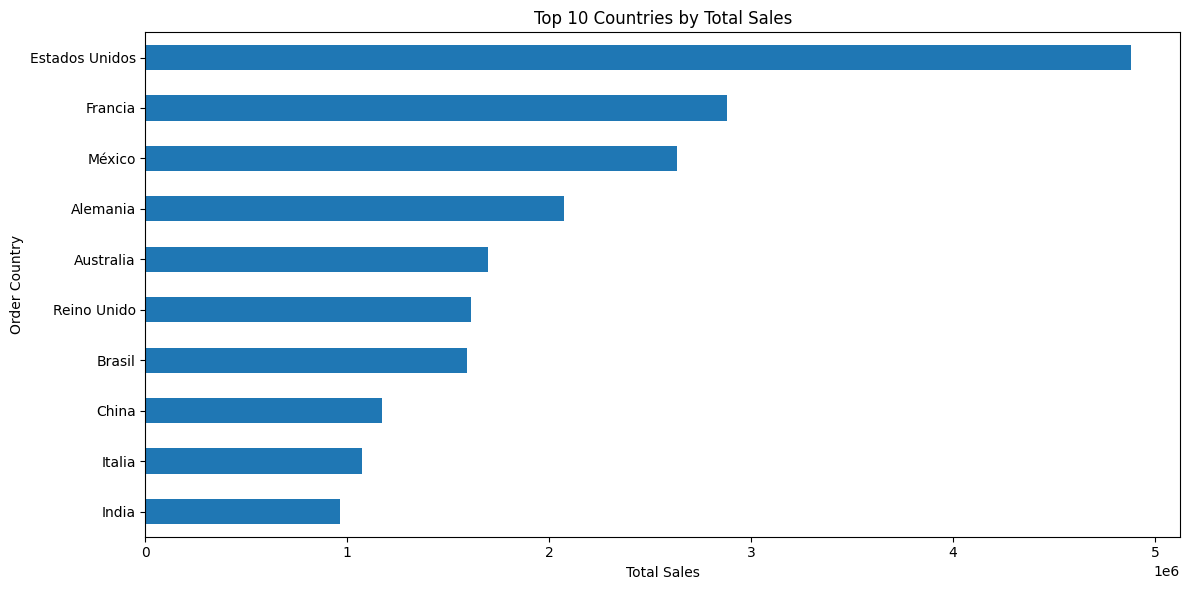

In [ ]:
top_10_countries = country_sales.head(10)

plt.figure(figsize=(12, 6))

top_10_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Order Country")
plt.tight_layout()
plt.show()

In [ ]:
department_sales = (
    df.groupby("Department Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(department_sales)

Department Name
Fan Shop              1.711387e+07
Apparel               7.976255e+06
Golf                  4.609028e+06
Footwear              4.006499e+06
Outdoors              1.253351e+06
Technology            1.039599e+06
Fitness               3.970509e+05
Discs Shop            2.288877e+05
Health and Beauty     1.060805e+05
Pet Shop              4.152480e+04
Book Shop             1.258740e+04
Name: Sales, dtype: float64


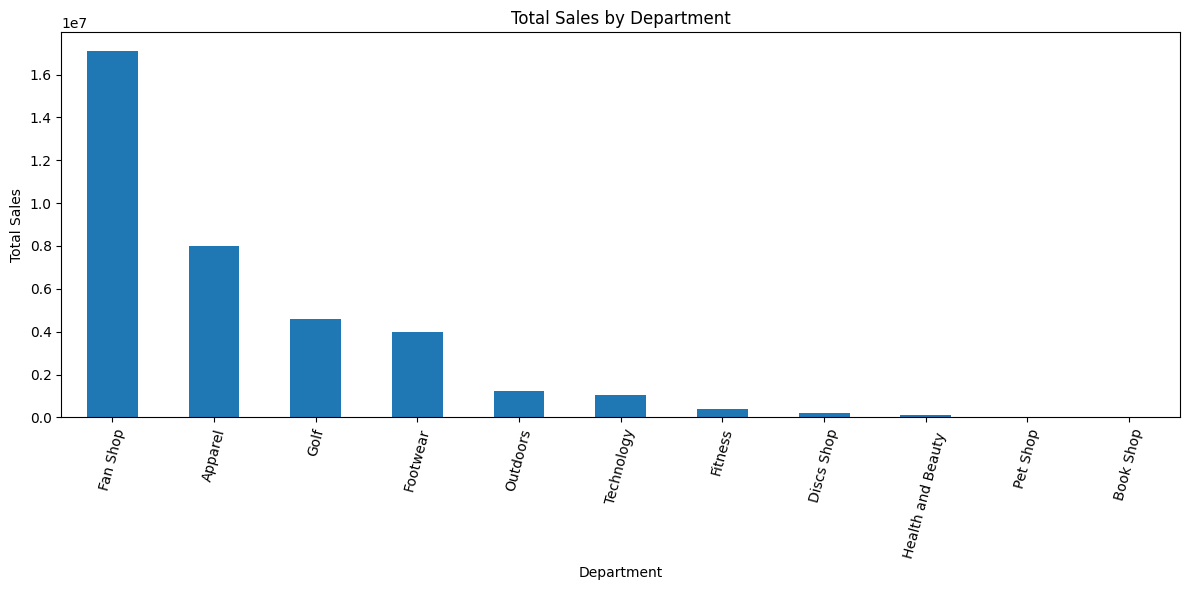

In [ ]:
plt.figure(figsize=(12, 6))

department_sales.plot(kind="bar")

plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:
department_profit = (
    df.groupby("Department Name")["Order Profit Per Order"]
      .sum()
      .sort_values(ascending=False)
)

print(department_profit)

Department Name
Fan Shop              1.834155e+06
Apparel               8.818829e+05
Golf                  4.975236e+05
Footwear              4.102225e+05
Outdoors              1.452515e+05
Technology            1.131700e+05
Fitness               4.653806e+04
Discs Shop            2.419312e+04
Health and Beauty     9.493630e+03
Pet Shop              3.589260e+03
Book Shop             8.830100e+02
Name: Order Profit Per Order, dtype: float64


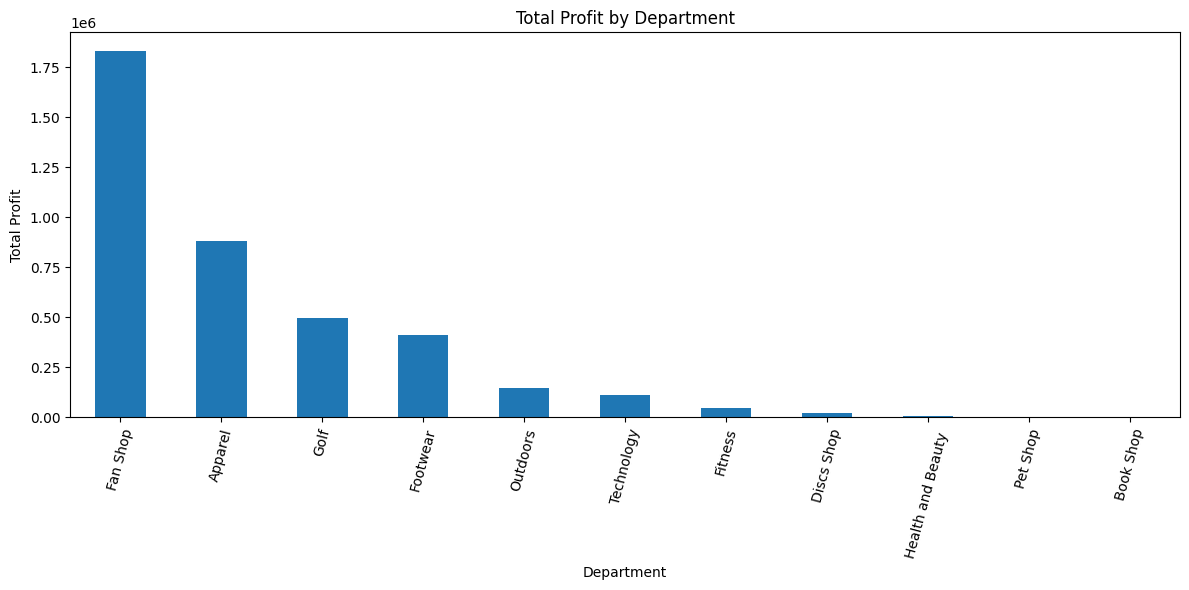

In [ ]:
plt.figure(figsize=(12, 6))

department_profit.plot(kind="bar")

plt.title("Total Profit by Department")
plt.xlabel("Department")
plt.ylabel("Total Profit")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:
monthly_orders = (
    df.groupby(["Order_Year", "Order_Month"])
      .size()
      .reset_index(name="Order_Count")
)

print(monthly_orders.head(12))

    Order_Year  Order_Month  Order_Count
0         2015            1         5322
1         2015            2         4729
2         2015            3         5362
3         2015            4         5126
4         2015            5         5357
5         2015            6         5134
6         2015            7         5299
7         2015            8         5273
8         2015            9         5140
9         2015           10         5302
10        2015           11         5235
11        2015           12         5371


In [ ]:
monthly_orders["Year_Month"] = pd.to_datetime(
    monthly_orders["Order_Year"].astype(str)
    + "-"
    + monthly_orders["Order_Month"].astype(str)
    + "-01"
)

monthly_orders = monthly_orders.sort_values("Year_Month")

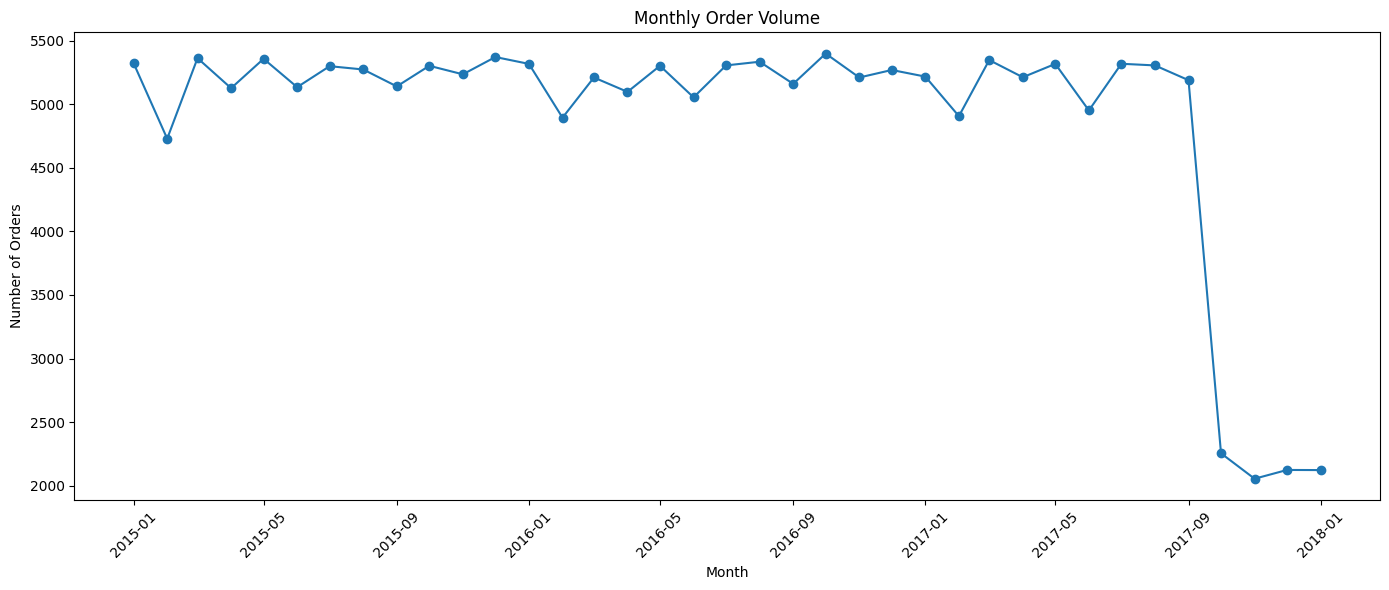

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_orders["Year_Month"],
    monthly_orders["Order_Count"],
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
region_delay = (
    df.groupby("Order Region")["Delivery_Delay"]
      .mean()
      .sort_values(ascending=False)
)

print(region_delay)

Order Region
Central Asia       0.645570
Central Africa     0.639833
South Asia         0.597465
Western Europe     0.597403
US Center          0.587226
East of USA        0.584816
South of  USA      0.579975
Eastern Europe     0.579847
East Africa        0.570734
West Asia          0.569479
Eastern Asia       0.566484
Central America    0.561942
Southeast Asia     0.558235
West of USA        0.557238
South America      0.556344
Oceania            0.556267
North Africa       0.552290
West Africa        0.550595
Northern Europe    0.546875
Caribbean          0.546526
Southern Europe    0.515640
Southern Africa    0.478825
Canada             0.391032
Name: Delivery_Delay, dtype: float64


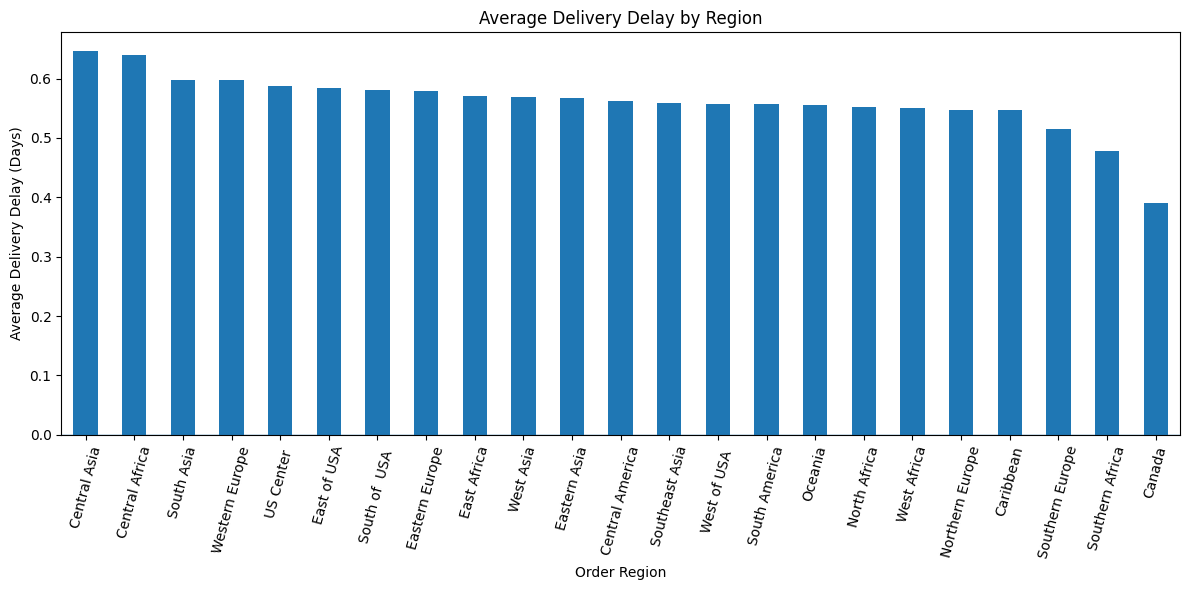

In [ ]:
plt.figure(figsize=(12, 6))

region_delay.plot(kind="bar")

plt.title("Average Delivery Delay by Region")
plt.xlabel("Order Region")
plt.ylabel("Average Delivery Delay (Days)")
plt.xticks(rotation=75)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
shipping_mode_sales = (
    df.groupby("Shipping Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(shipping_mode_sales)

Shipping Mode
Standard Class    2.202239e+07
Second Class      7.145445e+06
First Class       5.674370e+06
Same Day          1.942529e+06
Name: Sales, dtype: float64


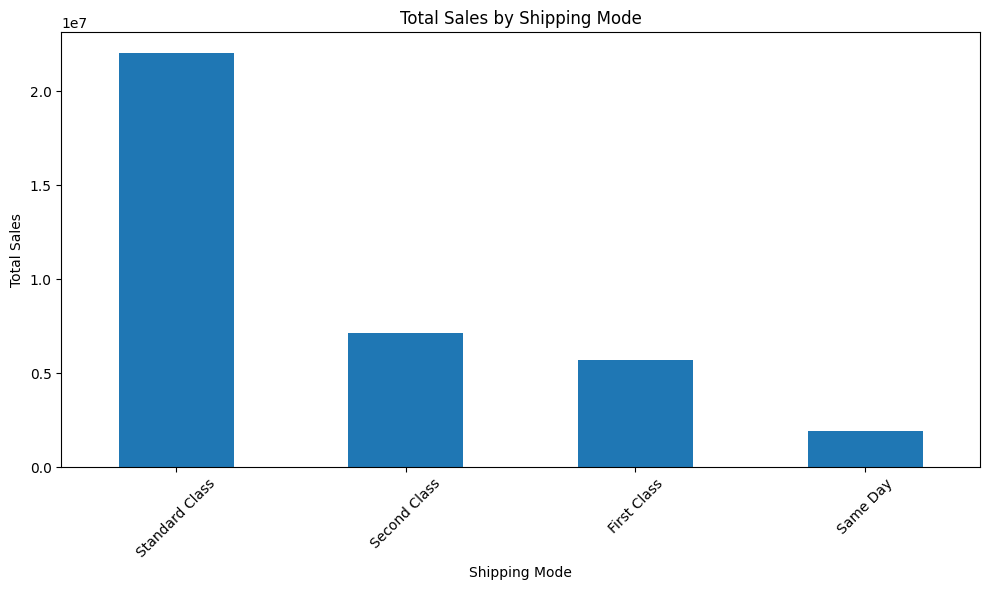

In [ ]:
plt.figure(figsize=(10, 6))

shipping_mode_sales.plot(kind="bar")

plt.title("Total Sales by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
sales_by_status = (
    df.groupby("Order Status")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_status)

Order Status
COMPLETE           1.209531e+07
PENDING_PAYMENT    8.106698e+06
PROCESSING         4.504064e+06
PENDING            4.120533e+06
CLOSED             4.022624e+06
ON_HOLD            1.981543e+06
SUSPECTED_FRAUD    8.259350e+05
CANCELED           7.443704e+05
PAYMENT_REVIEW     3.836537e+05
Name: Sales, dtype: float64


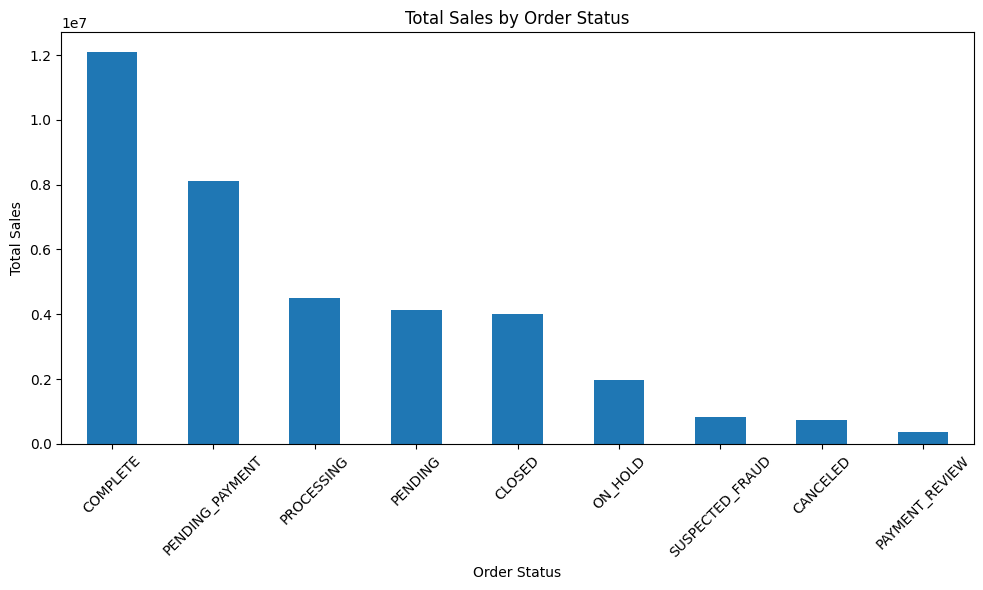

In [ ]:
plt.figure(figsize=(10, 6))

sales_by_status.plot(kind="bar")

plt.title("Total Sales by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
profit_by_status = (
    df.groupby("Order Status")["Order Profit Per Order"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_by_status)

Order Status
COMPLETE           1.321736e+06
PENDING_PAYMENT    8.438102e+05
PROCESSING         4.948259e+05
CLOSED             4.579811e+05
PENDING            4.357259e+05
ON_HOLD            2.089130e+05
SUSPECTED_FRAUD    8.513671e+04
CANCELED           7.534563e+04
PAYMENT_REVIEW     4.342879e+04
Name: Order Profit Per Order, dtype: float64


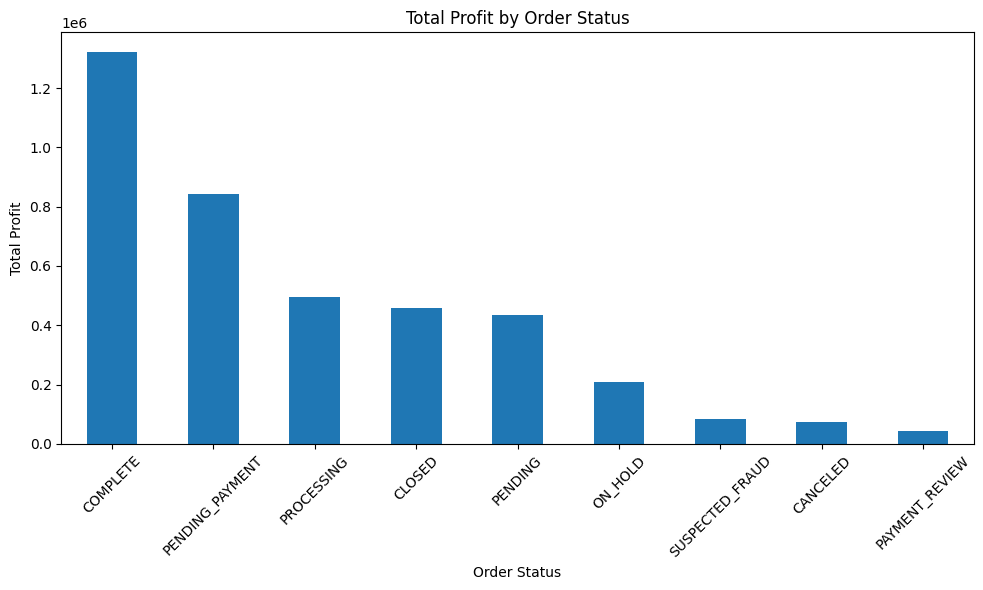

In [ ]:
plt.figure(figsize=(10, 6))

profit_by_status.plot(kind="bar")

plt.title("Total Profit by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
total_sales = df["Sales"].sum()
total_orders = len(df)
total_profit = df["Order Profit Per Order"].sum()
avg_delivery_delay = df["Delivery_Delay"].mean()
avg_sales_per_order = df["Sales"].mean()

print("===== SUPPLY CHAIN BUSINESS SUMMARY =====")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Delivery Delay: {avg_delivery_delay:.2f} days")
print(f"Average Sales per Order: ${avg_sales_per_order:,.2f}")

===== SUPPLY CHAIN BUSINESS SUMMARY =====
Total Sales: $36,784,735.01
Total Orders: 180,519
Total Profit: $3,966,902.97
Average Delivery Delay: 0.57 days
Average Sales per Order: $203.77


In [ ]:
print("Final Rows:", df.shape[0])
print("Final Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Final Rows: 180519
Final Columns: 58

Column Names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping da

In [ ]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [ ]:
final_path = "/content/drive/MyDrive/Supply_Chain_Analytics/01_Raw_Data/DataCoSupplyChainDataset_Final.csv"

df.to_csv(final_path, index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [ ]:
import os

final_path = "/content/drive/MyDrive/Supply_Chain_Analytics/01_Raw_Data/DataCoSupplyChainDataset_Final.csv"

print(os.path.exists(final_path))

True


In [ ]:
import os

for root, dirs, files_list in os.walk("/content/drive/MyDrive"):
    for file in files_list:
        if "DataCoSupplyChainDataset" in file:
            print(os.path.join(root, file))